# Employee Salary Prediction using Machine Learning

# 
 Problem Statement

Objective:

Build a machine learning model that predicts whether an employee's annual income is greater than $50,000 or less than or equal to $50,000 based on demographic, educational, and employment-related attributes.

The goal is to help organizations and analysts understand the key factors influencing salary levels and use historical employee data to make accurate income classification predictions.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv(r'C:\\Users\\Arjun Singh Tomar\\Downloads\\archive (13)\\adult.csv')

In [3]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


# Basic Data Inspection

In [4]:
df.tail()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [5]:
df.shape 

(32561, 15)

In [6]:
df.tail()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [8]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [9]:
df.sample(4)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
16409,37,Private,52221,11th,7,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,<=50K
12857,30,Private,149118,HS-grad,9,Divorced,Craft-repair,Not-in-family,White,Female,0,0,40,United-States,<=50K
21656,25,Self-emp-inc,454934,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,35,United-States,<=50K
25099,43,Private,180096,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,50,United-States,>50K


# Data Cleaning 

In [10]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(24)

In [12]:
df.drop_duplicates(inplace=True)  # to remove the duplicate value 

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

# Exploratory Data Analysis (EDA)

In [15]:
# univariate(categirical columns)
df["sex"].value_counts()

sex
Male      21775
Female    10762
Name: count, dtype: int64

<Axes: xlabel='sex', ylabel='count'>

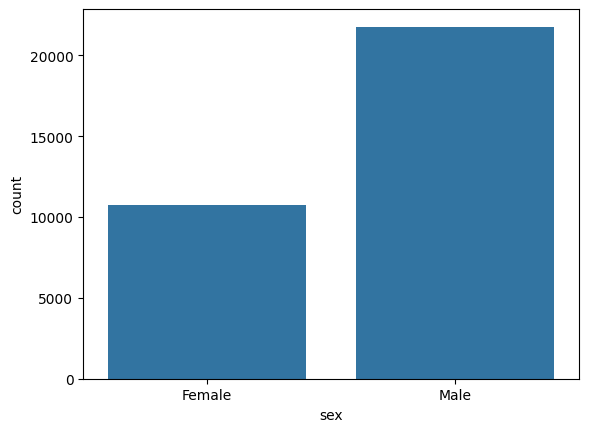

In [16]:
sns.countplot(x="sex",data=df)

In [17]:
df["native.country"].value_counts()

native.country
United-States                 29153
Mexico                          639
?                               582
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        62
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
Greece       

In [18]:
df["occupation"].value_counts()

occupation
Prof-specialty       4136
Craft-repair         4094
Exec-managerial      4065
Adm-clerical         3768
Sales                3650
Other-service        3291
Machine-op-inspct    2000
?                    1843
Transport-moving     1597
Handlers-cleaners    1369
Farming-fishing       992
Tech-support          927
Protective-serv       649
Priv-house-serv       147
Armed-Forces            9
Name: count, dtype: int64

In [19]:
df["workclass"].value_counts()

workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [20]:
df["marital.status"].value_counts()

marital.status
Married-civ-spouse       14970
Never-married            10667
Divorced                  4441
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

In [21]:
df["education"].value_counts()

education
HS-grad         10494
Some-college     7282
Bachelors        5353
Masters          1722
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           645
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           332
1st-4th           166
Preschool          50
Name: count, dtype: int64

<Axes: xlabel='marital.status', ylabel='count'>

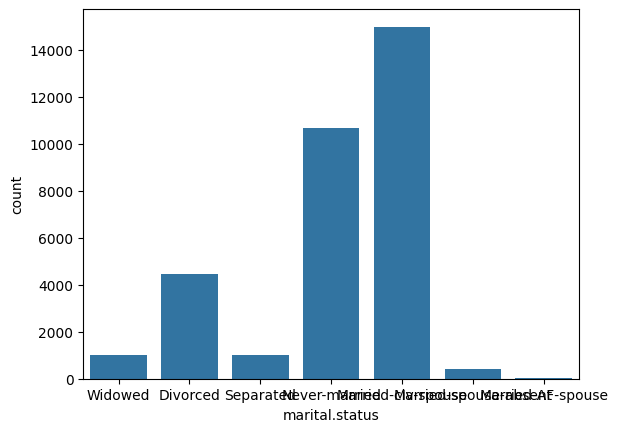

In [22]:
sns.countplot(x="marital.status",data=df)

<Axes: xlabel='workclass', ylabel='count'>

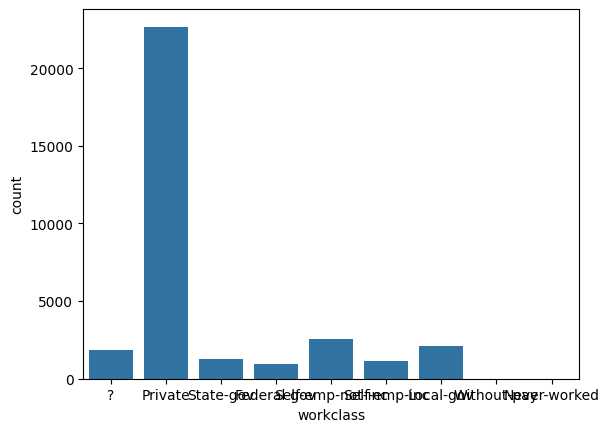

In [23]:
sns.countplot(x="workclass",data=df)

In [24]:
df["relationship"].value_counts()

relationship
Husband           13187
Not-in-family      8292
Own-child          5064
Unmarried          3445
Wife               1568
Other-relative      981
Name: count, dtype: int64

<Axes: xlabel='relationship', ylabel='count'>

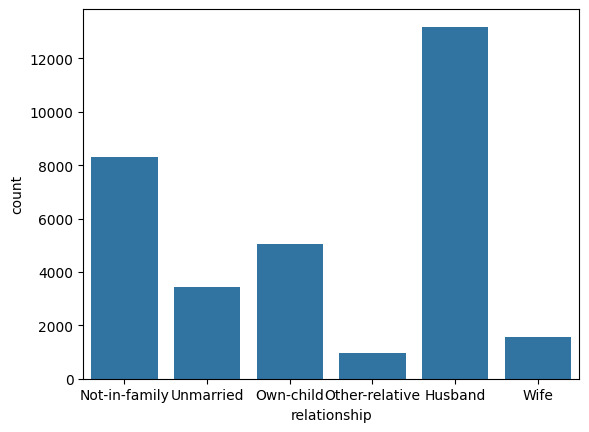

In [25]:
sns.countplot(x="relationship",data=df)

In [26]:
df["race"].value_counts()

race
White                 27795
Black                  3122
Asian-Pac-Islander     1038
Amer-Indian-Eskimo      311
Other                   271
Name: count, dtype: int64

<Axes: xlabel='race', ylabel='count'>

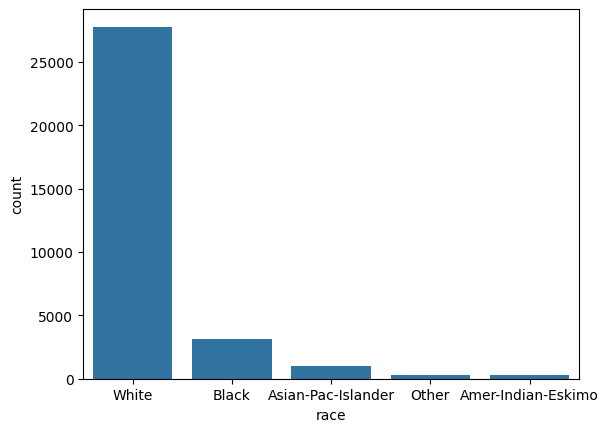

In [27]:
sns.countplot(x="race",data=df)

In [28]:
# (numerical column)

<Axes: xlabel='age', ylabel='Count'>

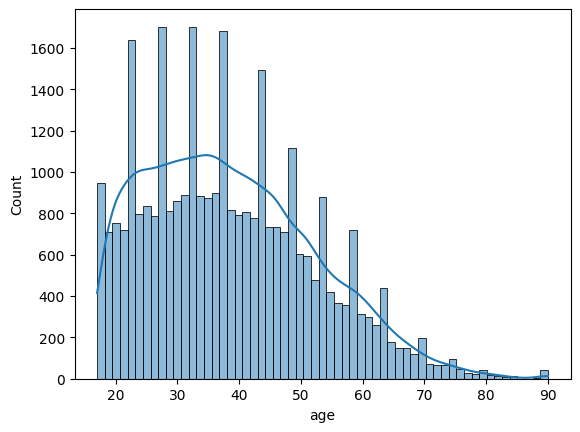

In [29]:
sns.histplot(df['age'],kde=True)

<Axes: xlabel='education.num', ylabel='Count'>

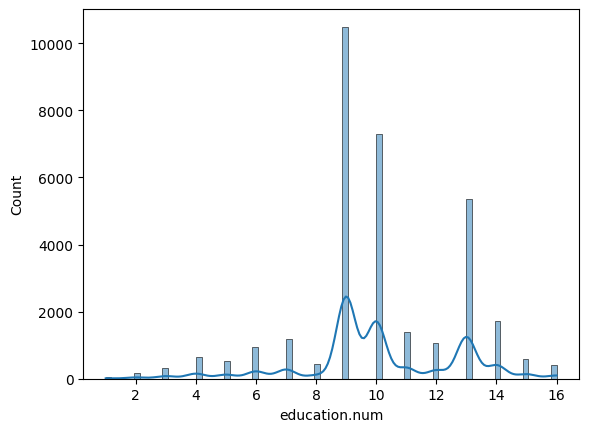

In [30]:
sns.histplot(df['education.num'],kde=True)

<Axes: xlabel='hours.per.week', ylabel='Count'>

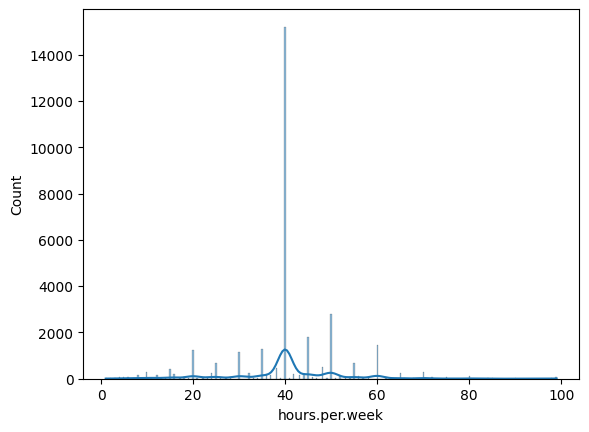

In [31]:
sns.histplot(df['hours.per.week'],kde=True)

<Axes: xlabel='capital.gain', ylabel='Count'>

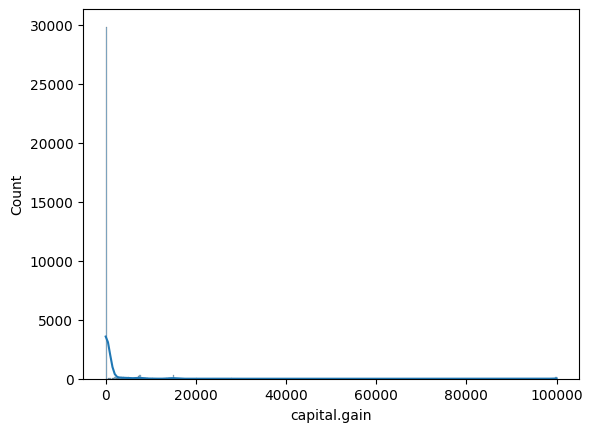

In [32]:
sns.histplot(df['capital.gain'],kde=True)

In [33]:
# bivariate
# cat vs cat column 
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


<Axes: xlabel='race', ylabel='count'>

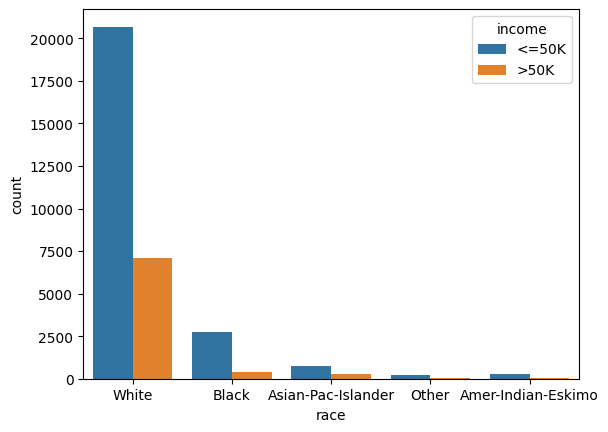

In [34]:
sns.countplot(x="race",hue="income",data= df)

<Axes: xlabel='sex', ylabel='count'>

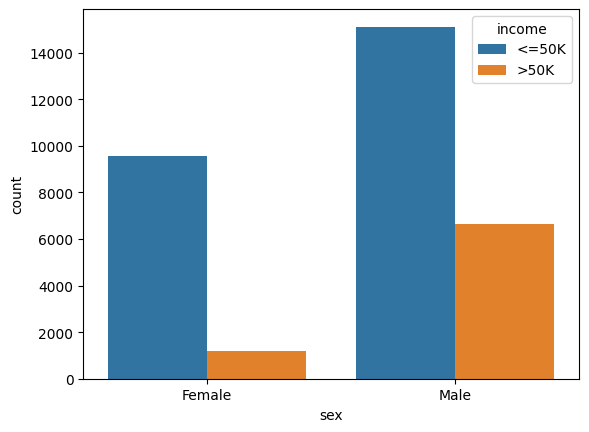

In [35]:
sns.countplot(x="sex",hue = "income",data=df)

In [36]:
pd.crosstab(df['relationship'],df['income'])

income,<=50K,>50K
relationship,,
Husband,7271,5916
Not-in-family,7436,856
Other-relative,944,37
Own-child,4997,67
Unmarried,3227,218
Wife,823,745


In [37]:
pd.crosstab(df['occupation'],df['income'])

income,<=50K,>50K
occupation,,
?,1652,191
Adm-clerical,3261,507
Armed-Forces,8,1
Craft-repair,3165,929
Exec-managerial,2097,1968
Farming-fishing,877,115
Handlers-cleaners,1283,86
Machine-op-inspct,1751,249
Other-service,3154,137


<Axes: xlabel='marital.status', ylabel='count'>

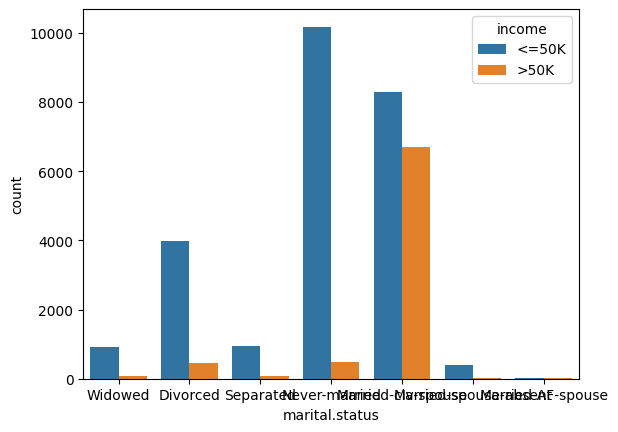

In [38]:
sns.countplot(x="marital.status",hue="income",data=df)

In [39]:
pd.crosstab(df['education'],df['income'])

income,<=50K,>50K
education,,
10th,871,62
11th,1115,60
12th,400,33
1st-4th,160,6
5th-6th,316,16
7th-8th,605,40
9th,487,27
Assoc-acdm,802,265
Assoc-voc,1021,361


In [40]:
pd.crosstab(df['workclass'],df['income'])

income,<=50K,>50K
workclass,,
?,1645,191
Federal-gov,589,371
Local-gov,1476,617
Never-worked,7,0
Private,17712,4961
Self-emp-inc,494,622
Self-emp-not-inc,1816,724
State-gov,945,353
Without-pay,14,0


In [41]:
# num vs num column 

In [42]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


<Axes: xlabel='age', ylabel='hours.per.week'>

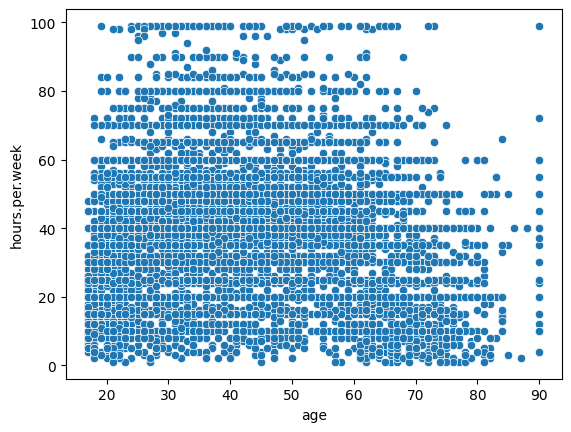

In [43]:
sns.scatterplot(x="age", y = "hours.per.week",data=df)

In [44]:
## num vs cat columns

<Axes: xlabel='sex', ylabel='hours.per.week'>

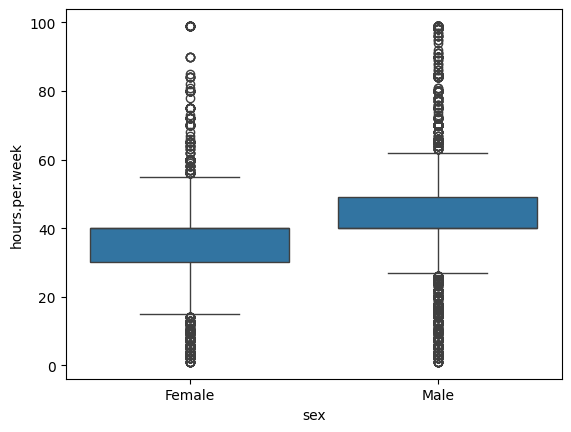

In [45]:
sns.boxplot(x="sex",y="hours.per.week",data=df)

<Axes: xlabel='race', ylabel='education.num'>

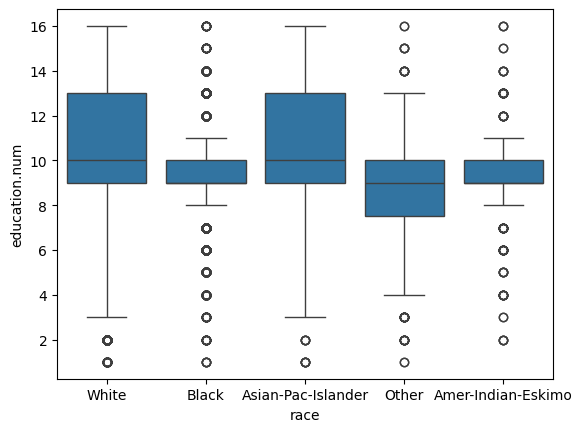

In [46]:
sns.boxplot(x="race",y="education.num",data=df)

<Axes: >

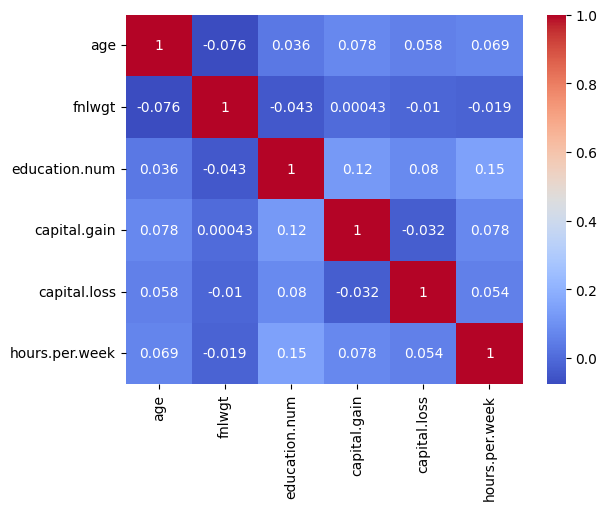

In [47]:
## multivariate (used correlation heatmap)
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

# Outlier analyse 

<Axes: xlabel='capital.gain'>

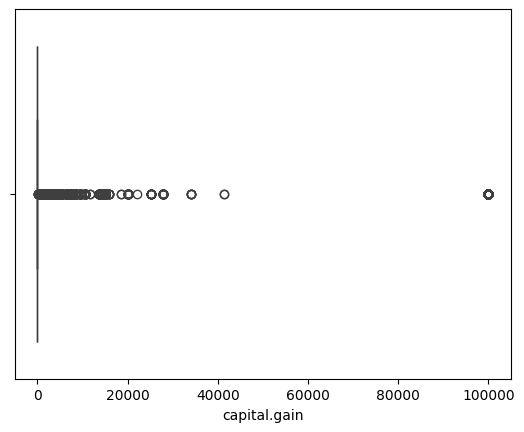

In [48]:
sns.boxplot(x=df['capital.gain'])

<Axes: xlabel='capital.loss'>

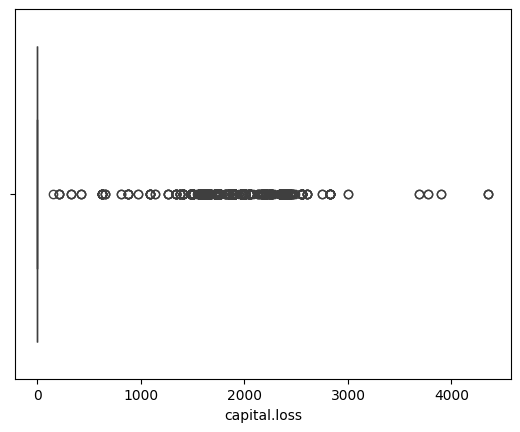

In [49]:
sns.boxplot(x=df['capital.loss'])

<Axes: xlabel='age'>

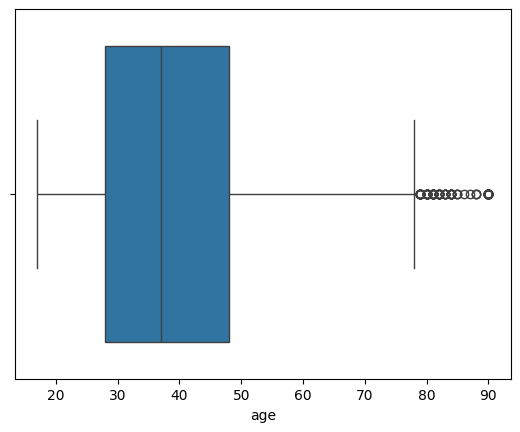

In [50]:
sns.boxplot(x=df['age'])

<Axes: xlabel='hours.per.week'>

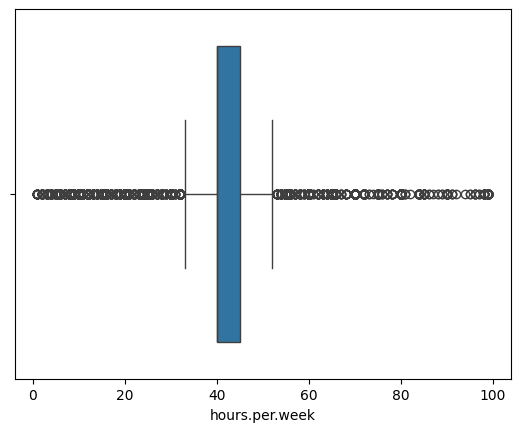

In [51]:
sns.boxplot(x=df['hours.per.week'])

# Feature Engineering

In [52]:
#### Create New Feature
df['total.capital'] = df['capital.gain']-df['capital.loss']

In [53]:
df['total.capital']

0       -4356
1       -4356
2       -4356
3       -3900
4       -3900
         ... 
32556       0
32557       0
32558       0
32559       0
32560       0
Name: total.capital, Length: 32537, dtype: int64

In [54]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,total.capital
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K,-4356
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K,-4356
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K,-4356
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K,-3900
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K,-3900


In [55]:
## feature selection 
df = df.drop(['education.num','fnlwgt'],axis=1)

In [56]:
df.head()

,age,workclass,education,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,total.capital
0,90,?,HS-grad,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K,-4356
1,82,Private,HS-grad,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K,-4356
2,66,?,Some-college,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K,-4356
3,54,Private,7th-8th,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K,-3900
4,41,Private,Some-college,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K,-3900


# Encoding 

In [57]:
## laabel encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['income'] = le.fit_transform(df['income'])

In [58]:
df['sex'] = le.fit_transform(df['sex'])

In [59]:
df.tail()

,age,workclass,education,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,total.capital
32556,22,Private,Some-college,Never-married,Protective-serv,Not-in-family,White,1,0,0,40,United-States,0,0
32557,27,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,0,0,0,38,United-States,0,0
32558,40,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,1,0,0,40,United-States,1,0
32559,58,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,0,0,0,40,United-States,0,0
32560,22,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,1,0,0,20,United-States,0,0


In [60]:
## ordinal encoding 
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(
    categories=[['HS-grad','Some-college','Bachelors','Masters','Assoc-voc','11th','Assoc-acdm','10th','7th-8th',
                                 '9th','12th','Prof-school','5th-6th','Doctorate','1st-4th','Preschool']]
)

df[['education']] = oe.fit_transform(df[['education']])

In [61]:
## onehot encoding 
df = pd.get_dummies(df,
               columns=['workclass','marital.status','occupation','relationship','race','native.country'],
               drop_first=True,dtype=int
              )

In [62]:
df.head()

,age,education,sex,capital.gain,capital.loss,hours.per.week,income,total.capital,workclass_Federal-gov,workclass_Local-gov,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,0.0,0,0,4356,40,0,-4356,0,0,...,0,0,0,0,0,0,0,1,0,0
1,82,0.0,0,0,4356,18,0,-4356,0,0,...,0,0,0,0,0,0,0,1,0,0
2,66,1.0,0,0,4356,40,0,-4356,0,0,...,0,0,0,0,0,0,0,1,0,0
3,54,8.0,0,0,3900,40,0,-3900,0,0,...,0,0,0,0,0,0,0,1,0,0
4,41,1.0,0,0,3900,40,0,-3900,0,0,...,0,0,0,0,0,0,0,1,0,0


# Train_Test_Split

In [63]:
# split X and y 
X = df.drop(columns=("income"),axis=1)
y = df['income']

In [64]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42
)

In [65]:
X_train.shape,X_test.shape

((21799, 85), (10738, 85))

In [66]:
y_train.shape,y_test.shape

((21799,), (10738,))

# Feature Scailing 

In [67]:
num_cols = [
    'age',
    'education',
    'capital.gain',
    'capital.loss',
    'hours.per.week'
]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [68]:
X_train[num_cols]

,age,education,capital.gain,capital.loss,hours.per.week
18119,0.910157,-0.763971,-0.146482,-0.217038,-0.036088
18004,-1.289773,-0.452830,-0.146482,-0.217038,-0.036088
20535,0.470171,-0.763971,-0.146482,-0.217038,-0.036088
4585,-0.409801,-0.452830,-0.146482,-0.217038,-0.036088
32353,-0.776456,-0.141690,-0.146482,-0.217038,-0.036088
...,...,...,...,...,...
29823,-0.556463,-0.763971,-0.146482,-0.217038,-0.036088
5390,0.910157,0.480592,-0.146482,-0.217038,-0.036088
860,1.203481,-0.763971,-0.146482,4.448620,-0.036088
15800,-1.143111,-0.141690,-0.146482,-0.217038,-1.250092


In [69]:
X_train.head()

,age,education,sex,capital.gain,capital.loss,hours.per.week,total.capital,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
18119,0.910157,-0.763971,1,-0.146482,-0.217038,-0.036088,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
18004,-1.289773,-0.452830,1,-0.146482,-0.217038,-0.036088,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
20535,0.470171,-0.763971,1,-0.146482,-0.217038,-0.036088,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4585,-0.409801,-0.452830,0,-0.146482,-0.217038,-0.036088,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
32353,-0.776456,-0.141690,1,-0.146482,-0.217038,-0.036088,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


# Machine Learning Model Train & Evaluation

In [70]:
#### Logistic Regression

from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(max_iter=5000,random_state=42)

In [71]:
classifier.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [72]:
y_pred = classifier.predict(X_test)
y_proba = classifier.predict_proba(X_test)[:,1]

In [73]:
y_pred

array([0, 0, 0, ..., 0, 1, 0], shape=(10738,))

In [74]:
y_proba

array([0.45139934, 0.0035234 , 0.24044791, ..., 0.00806091, 0.54190774,
       0.01744884], shape=(10738,))

In [75]:
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,precision_score,recall_score,f1_score
                            ,roc_auc_score,ConfusionMatrixDisplay)

In [76]:
print("the accuracy score is : ",accuracy_score(y_test,y_pred))
print("the precision score is :",precision_score(y_test,y_pred))
print("the recall score is ",recall_score(y_test,y_pred))
print("the f1 score is : ",f1_score(y_test,y_pred))
print("the roc_auc score is :",roc_auc_score(y_test,y_proba))

the accuracy score is :  0.841776867200596
the precision score is : 0.693327239488117
the recall score is  0.5960707269155207
the f1 score is :  0.6410310585252482
the roc_auc score is : 0.8933588666543413


In [77]:
print("the classification report")
print(classification_report(y_test,y_pred))

the classification report
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      8193
           1       0.69      0.60      0.64      2545

    accuracy                           0.84     10738
   macro avg       0.79      0.76      0.77     10738
weighted avg       0.84      0.84      0.84     10738



In [78]:
print("the confusion matrix is ")
cm = (confusion_matrix(y_test,y_pred))
print(cm)

the confusion matrix is 
[[7522  671]
 [1028 1517]]


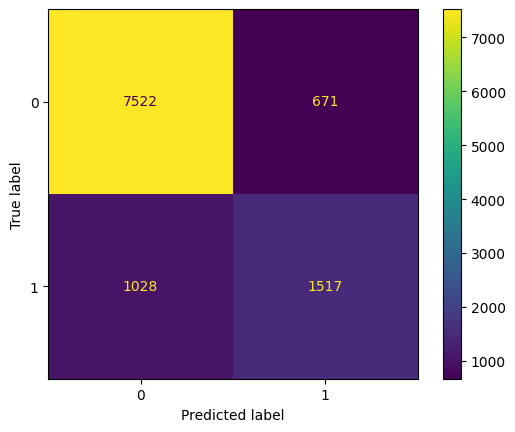

In [79]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

In [80]:
#### KNN Algorithm 

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [81]:
knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [82]:
y_pred_knn = knn.predict(X_test)
y_proba_knn = knn.predict_proba(X_test)[:,1]

In [83]:
y_pred_knn

array([0, 0, 0, ..., 0, 0, 0], shape=(10738,))

In [84]:
y_proba_knn

array([0. , 0. , 0.2, ..., 0. , 0.2, 0. ], shape=(10738,))

In [85]:
print("the accuracy is ",accuracy_score(y_test,y_pred_knn))
print("the precision is ",precision_score(y_test,y_pred_knn))
print("the f1 score is ",f1_score(y_test,y_pred_knn))
print("the recall score is ",recall_score(y_test,y_pred_knn))
print("the roc_auc score is ",roc_auc_score(y_test,y_proba_knn))

the accuracy is  0.8589122741665115
the precision is  0.7156616415410385
the f1 score is  0.6928846543685384
the recall score is  0.6715127701375245
the roc_auc score is  0.8910502928250842


In [86]:
print("the classification report is ")
print(classification_report(y_test,y_pred))

the classification report is 
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      8193
           1       0.69      0.60      0.64      2545

    accuracy                           0.84     10738
   macro avg       0.79      0.76      0.77     10738
weighted avg       0.84      0.84      0.84     10738



In [87]:
print("the confusion matrix ")
cm = (confusion_matrix(y_test,y_pred_knn))
print(cm)

the confusion matrix 
[[7514  679]
 [ 836 1709]]


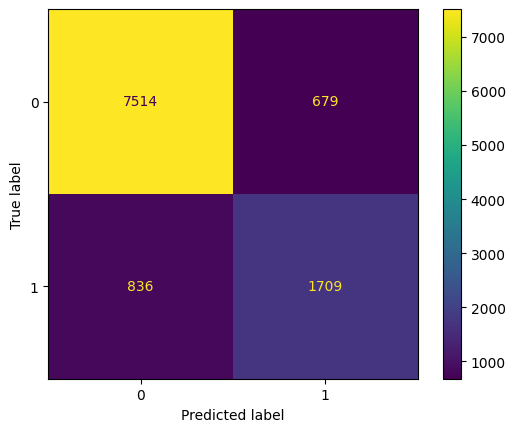

In [88]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

In [89]:
#### Decision Tree 

from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)

In [90]:
dt.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [91]:
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:,1]

In [92]:
y_pred_dt

array([0, 0, 0, ..., 0, 1, 1], shape=(10738,))

In [93]:
y_proba_dt

array([0., 0., 0., ..., 0., 1., 1.], shape=(10738,))

In [94]:
print("the accuracy score is ",accuracy_score(y_test,y_pred_dt))
print("the precision score is ",precision_score(y_test,y_pred_dt))
print("the recall score is ",recall_score(y_test,y_pred_dt))
print("the f1 score is ",f1_score(y_test,y_pred_dt))
print("the roc_auc score is",roc_auc_score(y_test,y_proba_dt))

the accuracy score is  0.8235239336934252
the precision score is  0.6294820717131474
the recall score is  0.6208251473477406
the f1 score is  0.6251236399604352
the roc_auc score is 0.7697617905169419


In [95]:
print("the classification report is ")
print(classification_report(y_test,y_pred_dt))

the classification report is 
              precision    recall  f1-score   support

           0       0.88      0.89      0.88      8193
           1       0.63      0.62      0.63      2545

    accuracy                           0.82     10738
   macro avg       0.76      0.75      0.75     10738
weighted avg       0.82      0.82      0.82     10738



In [96]:
print("the comfusion matrix is ")
cm = confusion_matrix(y_test,y_pred_dt)
print(cm)

the comfusion matrix is 
[[7263  930]
 [ 965 1580]]


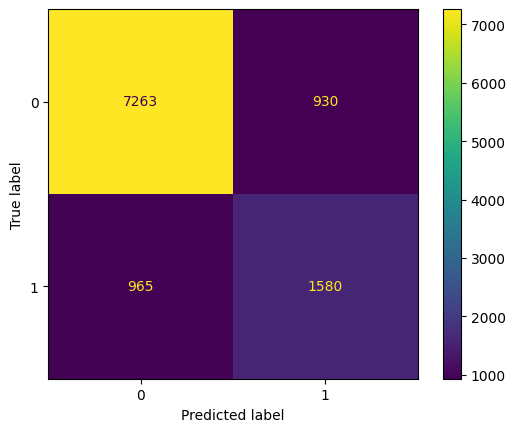

In [97]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

In [98]:
#### Random Forest


from sklearn.ensemble import RandomForestClassifier
rdt = RandomForestClassifier()

In [99]:
rdt.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [100]:
y_pred_rdt = rdt.predict(X_test)
y_proba_rdt = rdt.predict_proba(X_test)[:,1]

In [101]:
y_pred_rdt

array([0, 0, 0, ..., 0, 0, 0], shape=(10738,))

In [102]:
y_proba_rdt

array([0.36 , 0.   , 0.355, ..., 0.01 , 0.314, 0.01 ], shape=(10738,))

In [103]:
print("the accuracy is ",accuracy_score(y_test,y_pred_rdt))
print("the precision is ",precision_score(y_test,y_pred_rdt))
print("the recall is ",recall_score(y_test,y_pred_rdt))
print("the f1 score is ",f1_score(y_test,y_pred_rdt))
print("the roc_auc_score",roc_auc_score(y_test,y_proba_rdt))

the accuracy is  0.8531383870366921
the precision is  0.7186088527551943
the recall is  0.6251473477406679
the f1 score is  0.6686278629964278
the roc_auc_score 0.8992016760678109


In [104]:
print("the classification report is ")
print(classification_report(y_test,y_pred))

the classification report is 
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      8193
           1       0.69      0.60      0.64      2545

    accuracy                           0.84     10738
   macro avg       0.79      0.76      0.77     10738
weighted avg       0.84      0.84      0.84     10738



In [105]:
print("the confusion matrix is ")
cm = confusion_matrix(y_test,y_pred_rdt)
print(cm)

the confusion matrix is 
[[7570  623]
 [ 954 1591]]


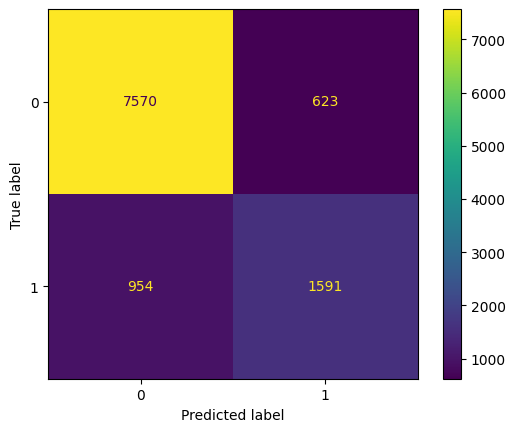

In [106]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

In [107]:
#### SVM Algo 


from sklearn.svm import SVC
svm = SVC(kernel='rbf',random_state=42)

In [108]:
svm.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [109]:
y_pred_svm =  svm.predict(X_test)

In [110]:
y_pred_svm

array([0, 0, 0, ..., 0, 0, 0], shape=(10738,))

In [111]:
print("the accuracy is ",accuracy_score(y_test,y_pred_svm))
print("the precision is ",precision_score(y_test,y_pred_svm))
print("the recall is ",recall_score(y_test,y_pred_svm))
print("the f1 score is ",f1_score(y_test,y_pred_svm))

the accuracy is  0.8059228906686534
the precision is  0.7403545359749739
the recall is  0.27897838899803534
the f1 score is  0.4052511415525114


In [112]:
print("the roc_auc_score")
y_scores = svm.decision_function(X_test)
roc_auc = roc_auc_score(y_test, y_scores)
print(roc_auc)

the roc_auc_score
0.8664153620046054


In [113]:
print("the classification report is ")
print(classification_report(y_test,y_pred_svm))

the classification report is 
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      8193
           1       0.74      0.28      0.41      2545

    accuracy                           0.81     10738
   macro avg       0.78      0.62      0.64     10738
weighted avg       0.80      0.81      0.77     10738



In [114]:
print("the confusion matrix is ")
cm = (confusion_matrix(y_test,y_pred_svm))
print(cm)

the confusion matrix is 
[[7944  249]
 [1835  710]]


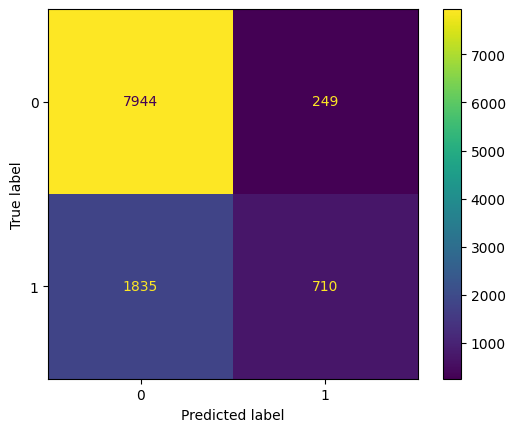

In [115]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

In [116]:
#### XGBoost Algo 


from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42)

C:\Users\Arjun Singh Tomar\anaconda3\Lib\site-packages\xgboost\compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [117]:
xgb.fit(X_train,y_train)

,base_score,0.5
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,1
,colsample_bynode,1
,colsample_bytree,1
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,gamma,0
,gpu_id,-1


In [118]:
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:,1]

In [119]:
y_pred_xgb

array([0, 0, 0, ..., 0, 0, 0], shape=(10738,))

In [120]:
y_proba_xgb

array([1.7500143e-02, 7.3650808e-05, 2.9044339e-01, ..., 1.6689453e-02,
       2.6084134e-01, 2.4348511e-03], shape=(10738,), dtype=float32)

In [121]:
print("the accuracy is ",accuracy_score(y_test,y_pred_xgb))
print("the precision is ",precision_score(y_test,y_pred_xgb))
print("the recall is",recall_score(y_test,y_pred_xgb))
print("the f1 score is",f1_score(y_test,y_pred_xgb))
print("the rocauc score is ",roc_auc_score(y_test,y_proba_xgb))

the accuracy is  0.8719500838144906
the precision is  0.763751127141569
the recall is 0.6656188605108055
the f1 score is 0.7113163972286374
the rocauc score is  0.9261619183753825


In [122]:
print("the classification report is ")
print(classification_report(y_test,y_pred_xgb))

the classification report is 
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      8193
           1       0.76      0.67      0.71      2545

    accuracy                           0.87     10738
   macro avg       0.83      0.80      0.81     10738
weighted avg       0.87      0.87      0.87     10738



In [123]:
print("the confusion matrix is ")
cm = confusion_matrix(y_test,y_pred_xgb)
print(cm)

the confusion matrix is 
[[7669  524]
 [ 851 1694]]


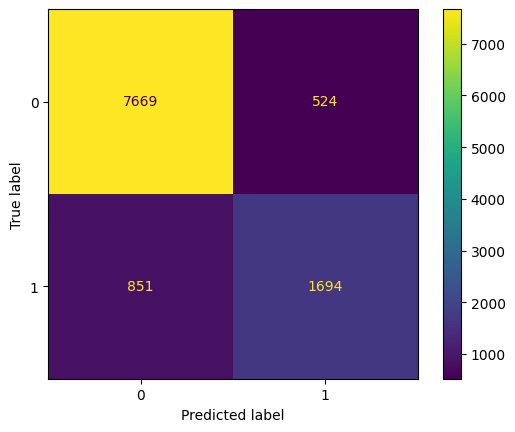

In [124]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

In [125]:
####  LightGBM algo 


from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(random_state=42,verbose=-1,n_jobs=1)

In [126]:
lgbm.fit(X_train,y_train)

,random_state,42
,n_jobs,1
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [127]:
y_pred_lgbm = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:,1]

In [128]:
y_pred_lgbm

array([0, 0, 0, ..., 0, 0, 0], shape=(10738,))

In [129]:
y_proba_lgbm

array([4.35741328e-02, 3.47748828e-04, 3.24892696e-01, ...,
       1.81871452e-02, 3.63074108e-01, 2.14744544e-02], shape=(10738,))

In [130]:
print("the accuracy is ",accuracy_score(y_test,y_pred_lgbm))
print("the precision is ",precision_score(y_test,y_pred_lgbm))
print("the recall is ",recall_score(y_test,y_pred_lgbm))
print("the f1 score is ",f1_score(y_test,y_pred_lgbm))
print("the rocauc is ",roc_auc_score(y_test,y_proba_lgbm))

the accuracy is  0.8741851368970013
the precision is  0.7728519195612431
the recall is  0.6644400785854617
the f1 score is  0.7145573631945912
the rocauc is  0.925406877354932


In [131]:
print("the classification report is ")
print(classification_report(y_test,y_pred_lgbm))

the classification report is 
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      8193
           1       0.77      0.66      0.71      2545

    accuracy                           0.87     10738
   macro avg       0.84      0.80      0.82     10738
weighted avg       0.87      0.87      0.87     10738



In [132]:
print("the confusion matrix is ")
cm = confusion_matrix(y_test,y_pred_lgbm)
print(cm)

the confusion matrix is 
[[7696  497]
 [ 854 1691]]


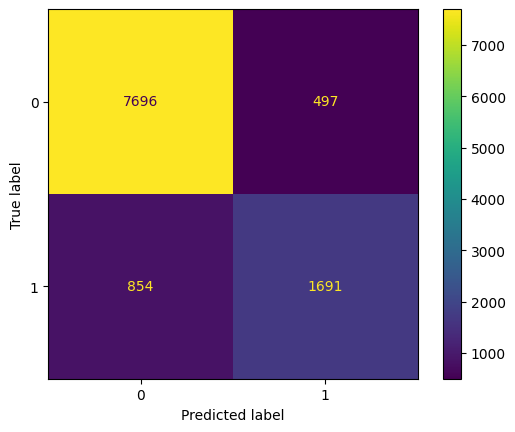

In [133]:
ConfusionMatrixDisplay(confusion_matrix = cm).plot()
plt.show()

In [134]:
#### Cat boost 


from catboost import CatBoostClassifier
cat = CatBoostClassifier(verbose=0,random_state=42)


In [135]:
cat.fit(X_train ,y_train )

CatBoostClassifier(random_state=42, verbose=0)

In [136]:
y_pred_cat = cat.predict(X_test)
y_proba_cat = cat.predict_proba(X_test)[:,1]

In [137]:
y_pred_cat

array([0, 0, 0, ..., 0, 0, 0], shape=(10738,))

In [138]:
y_proba_cat

array([0.06062065, 0.00035627, 0.33632181, ..., 0.02544868, 0.21247897,
       0.01648848], shape=(10738,))

In [139]:
print("the accuracy is ",accuracy_score(y_test,y_pred_cat))
print("the precision is ",precision_score(y_test,y_pred_cat))
print("the recall is ",recall_score(y_test,y_pred_cat))
print("the f1 score is ",f1_score(y_test,y_pred_cat))
print("the rocauc score ",roc_auc_score(y_test,y_proba_cat))

the accuracy is  0.8738126280499162
the precision is  0.7711941659070192
the recall is  0.6648330058939096
the f1 score is  0.7140746993036505
the rocauc score  0.9262718641650344


In [140]:
print("the classification report is ")
print(classification_report(y_test,y_pred_cat))

the classification report is 
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      8193
           1       0.77      0.66      0.71      2545

    accuracy                           0.87     10738
   macro avg       0.84      0.80      0.82     10738
weighted avg       0.87      0.87      0.87     10738



In [141]:
print("the confusion matrix is ")
cm = confusion_matrix(y_test,y_pred_cat)
print(cm)

the confusion matrix is 
[[7691  502]
 [ 853 1692]]


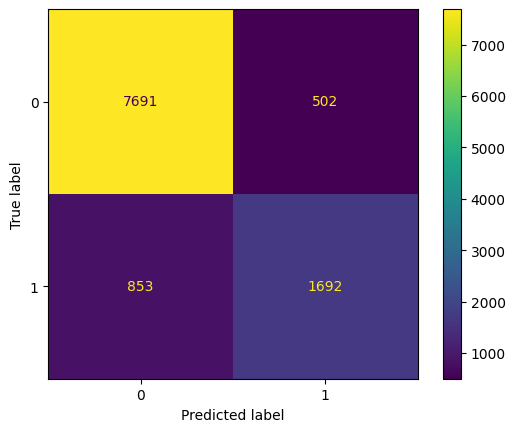

In [142]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

# Compare the Model

In [143]:
result=[]

In [144]:
result.append([
    "Logistic Regression",
    accuracy_score(y_test,y_pred),
    precision_score(y_test,y_pred),
    recall_score(y_test,y_pred),
    f1_score(y_test,y_pred),
    roc_auc_score(y_test,y_proba),
])

In [145]:
result.append([
    "KNN",
    accuracy_score(y_test,y_pred_knn),
    precision_score(y_test,y_pred_knn),
    recall_score(y_test,y_pred_knn),
    f1_score(y_test,y_pred_knn),
    roc_auc_score(y_test,y_proba_knn)
])

In [146]:
result.append([
    "Decision Tree",
    accuracy_score(y_test,y_pred_dt),
    precision_score(y_test,y_pred_dt),
    recall_score(y_test,y_pred_dt),
    f1_score(y_test,y_pred_dt),
    roc_auc_score(y_test,y_proba_dt),
])

In [147]:
result.append([
    "Random Forest",
    accuracy_score(y_test,y_pred_rdt),
    precision_score(y_test,y_pred_rdt),
    recall_score(y_test,y_pred_rdt),
    f1_score(y_test,y_pred_rdt),
    roc_auc_score(y_test,y_proba_rdt)
])

In [148]:
result.append([
    "SVm",
    accuracy_score(y_test,y_pred_svm),
    precision_score(y_test,y_pred_svm),
    recall_score(y_test,y_pred_svm),
    f1_score(y_test,y_pred_svm),
    roc_auc_score(y_test,y_scores)
])

In [149]:
result.append([
    "xgboost",
    accuracy_score(y_test,y_pred_xgb),
    precision_score(y_test,y_pred_xgb),
    recall_score(y_test,y_pred_xgb),
    f1_score(y_test,y_pred_xgb),
    roc_auc_score(y_test,y_proba_xgb)
])

In [150]:
result.append([
    "lightgbm",
    accuracy_score(y_test,y_pred_lgbm),
    precision_score(y_test,y_pred_lgbm),
    recall_score(y_test,y_pred_lgbm),
    f1_score(y_test,y_pred_lgbm),
    roc_auc_score(y_test,y_proba_lgbm)
])

In [151]:
result.append([
    "catboost",
    accuracy_score(y_test,y_pred_cat),
    precision_score(y_test,y_pred_cat),
    recall_score(y_test,y_pred_cat),
    f1_score(y_test,y_pred_cat),
    roc_auc_score(y_test,y_proba_cat)
])

In [152]:
comparison = pd.DataFrame(
    result,
    columns = [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1_score",
        "Roc_Auc_score"
    ]
)

In [153]:
print("the comparison table is : ")
comparison

the comparison table is : 


,Model,Accuracy,Precision,Recall,F1_score,Roc_Auc_score
0,Logistic Regression,0.841777,0.693327,0.596071,0.641031,0.893359
1,KNN,0.858912,0.715662,0.671513,0.692885,0.891050
2,Decision Tree,0.823524,0.629482,0.620825,0.625124,0.769762
3,Random Forest,0.853138,0.718609,0.625147,0.668628,0.899202
4,SVm,0.805923,0.740355,0.278978,0.405251,0.866415
5,xgboost,0.871950,0.763751,0.665619,0.711316,0.926162
6,lightgbm,0.874185,0.772852,0.664440,0.714557,0.925407
7,catboost,0.873813,0.771194,0.664833,0.714075,0.926272


In [154]:
comparison.sort_values(by = "Roc_Auc_score",ascending=False)

,Model,Accuracy,Precision,Recall,F1_score,Roc_Auc_score
7,catboost,0.873813,0.771194,0.664833,0.714075,0.926272
5,xgboost,0.871950,0.763751,0.665619,0.711316,0.926162
6,lightgbm,0.874185,0.772852,0.664440,0.714557,0.925407
3,Random Forest,0.853138,0.718609,0.625147,0.668628,0.899202
0,Logistic Regression,0.841777,0.693327,0.596071,0.641031,0.893359
1,KNN,0.858912,0.715662,0.671513,0.692885,0.891050
4,SVm,0.805923,0.740355,0.278978,0.405251,0.866415
2,Decision Tree,0.823524,0.629482,0.620825,0.625124,0.769762


In [155]:
comparison.sort_values(by = "F1_score",ascending=False)

,Model,Accuracy,Precision,Recall,F1_score,Roc_Auc_score
6,lightgbm,0.874185,0.772852,0.664440,0.714557,0.925407
7,catboost,0.873813,0.771194,0.664833,0.714075,0.926272
5,xgboost,0.871950,0.763751,0.665619,0.711316,0.926162
1,KNN,0.858912,0.715662,0.671513,0.692885,0.891050
3,Random Forest,0.853138,0.718609,0.625147,0.668628,0.899202
0,Logistic Regression,0.841777,0.693327,0.596071,0.641031,0.893359
2,Decision Tree,0.823524,0.629482,0.620825,0.625124,0.769762
4,SVm,0.805923,0.740355,0.278978,0.405251,0.866415


In [156]:
comparison.sort_values(by = "Accuracy",ascending=False)

,Model,Accuracy,Precision,Recall,F1_score,Roc_Auc_score
6,lightgbm,0.874185,0.772852,0.664440,0.714557,0.925407
7,catboost,0.873813,0.771194,0.664833,0.714075,0.926272
5,xgboost,0.871950,0.763751,0.665619,0.711316,0.926162
1,KNN,0.858912,0.715662,0.671513,0.692885,0.891050
3,Random Forest,0.853138,0.718609,0.625147,0.668628,0.899202
0,Logistic Regression,0.841777,0.693327,0.596071,0.641031,0.893359
2,Decision Tree,0.823524,0.629482,0.620825,0.625124,0.769762
4,SVm,0.805923,0.740355,0.278978,0.405251,0.866415


In [157]:
best_model = comparison.sort_values(by = ["Roc_Auc_score","F1_score","Accuracy"],ascending=False)

In [158]:
best_model.head(3)

,Model,Accuracy,Precision,Recall,F1_score,Roc_Auc_score
7,catboost,0.873813,0.771194,0.664833,0.714075,0.926272
5,xgboost,0.871950,0.763751,0.665619,0.711316,0.926162
6,lightgbm,0.874185,0.772852,0.664440,0.714557,0.925407


# Model Comparison Conclusion

After comparing all the classification models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC, LightGBM, CatBoost, and XGBoost showed the strongest overall performance.

LightGBM achieved the highest Accuracy (87.42%) and F1-Score (71.46%), while CatBoost achieved the highest ROC-AUC (92.63%). Since the performance of these three models was very close, they were selected for hyperparameter tuning to determine the final best-performing model.

# Hyperparamter Tunning

In [159]:
from sklearn.model_selection import GridSearchCV

In [160]:
# catboost

# CatBoost

parameter = {
    'iterations': [100, 200],
    'learning_rate': [ 0.1, 0.05],
    'depth': [4, 6],
    'l2_leaf_reg': [1, 3]
}

In [161]:
grid_cat = GridSearchCV(estimator = cat,param_grid = parameter,cv=5,scoring=f1_score,n_jobs=-1,verbose=1)
grid_cat.fit(X_train,y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


C:\Users\Arjun Singh Tomar\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostClass...42, verbose=0)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'depth': [4, 6], 'iterations': [100, 200], 'l2_leaf_reg': [1, 3], 'learning_rate': [0.1, 0.05]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",<function f1_...0014799EEA200>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examp

In [162]:
best_cat = grid_cat.best_estimator_

In [163]:
print(grid_cat.best_params_)

{'depth': 4, 'iterations': 100, 'l2_leaf_reg': 1, 'learning_rate': 0.1}


In [164]:
print(grid_cat.best_score_)

nan


In [165]:
y_pred_cat = best_cat.predict(X_test)
y_proba_cat = best_cat.predict_proba(X_test)[:, 1]

In [166]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,
                             classification_report,confusion_matrix,ConfusionMatrixDisplay)

In [167]:
print("the new accuracy is",accuracy_score(y_test,y_pred_cat))
print("the new precision is",precision_score(y_test,y_pred_cat))
print("the new recall is",recall_score(y_test,y_pred_cat))
print("the new f1 score is ",f1_score(y_test,y_pred_cat))
print("the new rocauc is ",roc_auc_score(y_test,y_proba_cat))

the new accuracy is 0.8667349599552989
the new precision is 0.7889004149377593
the new recall is 0.5976424361493123
the new f1 score is  0.6800804828973843
the new rocauc is  0.9179710169949573


In [168]:
### xgboost 

parameter = {
    'n_estimators' : [100,200],
    'learning_rate' : [0.01,0.1],
    'max_depth' : [3,5],
    'subsample' : [0.8,1.0]
}

In [169]:
grid_xgb = GridSearchCV(estimator = xgb,param_grid=parameter,cv=3,scoring =f1_score,n_jobs=-1,verbose=1)

In [170]:
grid_xgb.fit(X_train,y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


C:\Users\Arjun Singh Tomar\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...lambda=1, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",<function f1_...0014799EEA200>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_au

In [171]:
best_xgb = grid_xgb.best_estimator_

In [172]:
grid_xgb.best_params_

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

In [173]:
grid_xgb.best_score_

np.float64(nan)

In [174]:
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:,1]

In [175]:
print("the new accuracy is ",accuracy_score(y_test,y_pred_xgb))
print("the new precison is ",precision_score(y_test,y_pred_xgb))
print("the new recall is ",recall_score(y_test,y_pred_xgb))
print("the new f1 score is ",f1_score(y_test,y_pred_xgb))
print("the new rocauc is ",roc_auc_score(y_test,y_proba_xgb))

the new accuracy is  0.8236170609051965
the new precison is  0.9369127516778524
the new recall is  0.2742632612966601
the new f1 score is  0.4243161094224924
the new rocauc is  0.8847993771097423


In [176]:
### lightgbm 

parameter_lgbm = {
    'n_estimators' : [100,200],
    'learning_rate' : [0.05,0.1],
    'max_depth' : [3,5],
    'num_leaves' : [15,31]
}


In [177]:
from sklearn.metrics import f1_score, make_scorer

f1 = make_scorer(f1_score)

grid_lgbm = GridSearchCV(estimator=lgbm,param_grid=parameter_lgbm,cv=3,scoring=f1,n_jobs=1,verbose=1,error_score='raise')

In [178]:
grid_lgbm.fit(X_train,y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...2, verbose=-1)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200], 'num_leaves': [15, 31]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearch

In [179]:
best_lgbm = grid_lgbm.best_estimator_

In [180]:
grid_lgbm.best_params_

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'num_leaves': 15}

In [181]:
grid_lgbm.best_score_

np.float64(0.7116825165554198)

In [182]:
y_pred_lgbm = best_lgbm.predict(X_test)
y_proba_lgbm = best_lgbm.predict_proba(X_test)[:,1]

In [183]:
print("the new accuracy is",accuracy_score(y_test,y_pred_lgbm))
print("the new precisionn is ",precision_score(y_test,y_pred_lgbm))
print("the new recall is",recall_score(y_test,y_pred_lgbm))
print("the new f1 score is ",f1_score(y_test,y_pred_lgbm))
print("the new rocauc is ",roc_auc_score(y_test,y_proba_lgbm))

the new accuracy is 0.8737195008381449
the new precisionn is  0.7761263353460288
the new recall is 0.656581532416503
the new f1 score is  0.7113665389527458
the new rocauc is  0.9267740898179169


# Compare the best model 

In [184]:
tuned_result = []

In [185]:
tuned_result.append([
    "catboost",
    accuracy_score(y_test,y_pred_cat),
    precision_score(y_test,y_pred_cat),
    recall_score(y_test,y_pred_cat),
    f1_score(y_test,y_pred_cat),
    roc_auc_score(y_test,y_proba_cat)
])

In [186]:
tuned_result.append([
    "xgboost",
    accuracy_score(y_test,y_pred_xgb),
    precision_score(y_test,y_pred_xgb),
    recall_score(y_test,y_pred_xgb),
    f1_score(y_test,y_pred_xgb),
    roc_auc_score(y_test,y_proba_xgb),
])

In [187]:
tuned_result.append([
    "lightgbm",
    accuracy_score(y_test,y_pred_lgbm),
    precision_score(y_test,y_pred_lgbm),
    recall_score(y_test,y_pred_lgbm),
    f1_score(y_test,y_pred_lgbm),
    roc_auc_score(y_test,y_proba_lgbm)
])

In [188]:
tuned_comparision = pd.DataFrame(
    tuned_result,
    columns = [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "RocAuc"
    ]
)

In [189]:
tuned_comparision

,Model,Accuracy,Precision,Recall,F1,RocAuc
0,catboost,0.866735,0.788900,0.597642,0.680080,0.917971
1,xgboost,0.823617,0.936913,0.274263,0.424316,0.884799
2,lightgbm,0.873720,0.776126,0.656582,0.711367,0.926774


In [190]:
tuned_comparision.sort_values(by=["F1","RocAuc"],ascending=False)

,Model,Accuracy,Precision,Recall,F1,RocAuc
2,lightgbm,0.873720,0.776126,0.656582,0.711367,0.926774
0,catboost,0.866735,0.788900,0.597642,0.680080,0.917971
1,xgboost,0.823617,0.936913,0.274263,0.424316,0.884799


In [191]:
final_best_model = best_lgbm

# Final Model Comparison Conclusion

After comparing all the machine learning algorithms based on Accuracy, Precision, Recall, F1-Score, and ROC-AUC, LightGBM achieved the best overall performance. Therefore, LightGBM was selected as the final model for this project because it provided the best balance between classification performance and predictive capability.

# Cross Validation on the final best Model

In [192]:
from sklearn.model_selection import cross_val_score

cv_score = cross_val_score(
    lgbm,
    X_train,y_train,
    cv=5,
    scoring = 'f1'
)

print("cv score ",cv_score)
print("Mean CV F1:", cv_score.mean())

cv score  [0.71841705 0.7073423  0.70435685 0.71966959 0.72359778]
Mean CV F1: 0.7146767116449945


# Feature Importance on the best model

In [193]:
feature_importance = pd.DataFrame({
    'Features' : X_train.columns,
    'Importance' : lgbm.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by = 'Importance',
    ascending = False
)

In [194]:
feature_importance.head(10)

,Features,Importance
0,age,616
1,education,395
5,hours.per.week,337
3,capital.gain,288
4,capital.loss,146
6,total.capital,104
16,marital.status_Married-civ-spouse,72
12,workclass_Self-emp-not-inc,65
30,occupation_Prof-specialty,64
2,sex,58


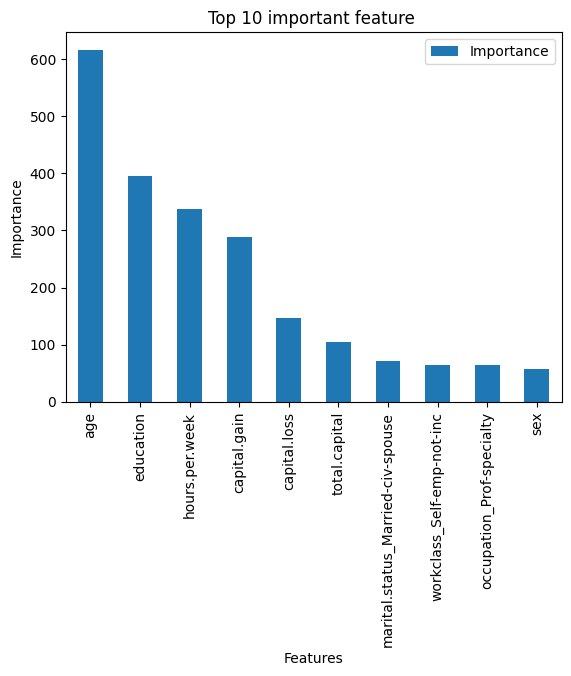

In [195]:
# graph 

feature_importance.head(10).plot(
    x='Features',
    y='Importance',
    kind = 'bar'
)

plt.title('Top 10 important feature ')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

# SHAP

In [196]:
import shap

In [197]:
explainer = shap.TreeExplainer(lgbm)

In [198]:
explainer

In [199]:
shap_values = explainer.shap_values(X_test)

C:\Users\Arjun Singh Tomar\anaconda3\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


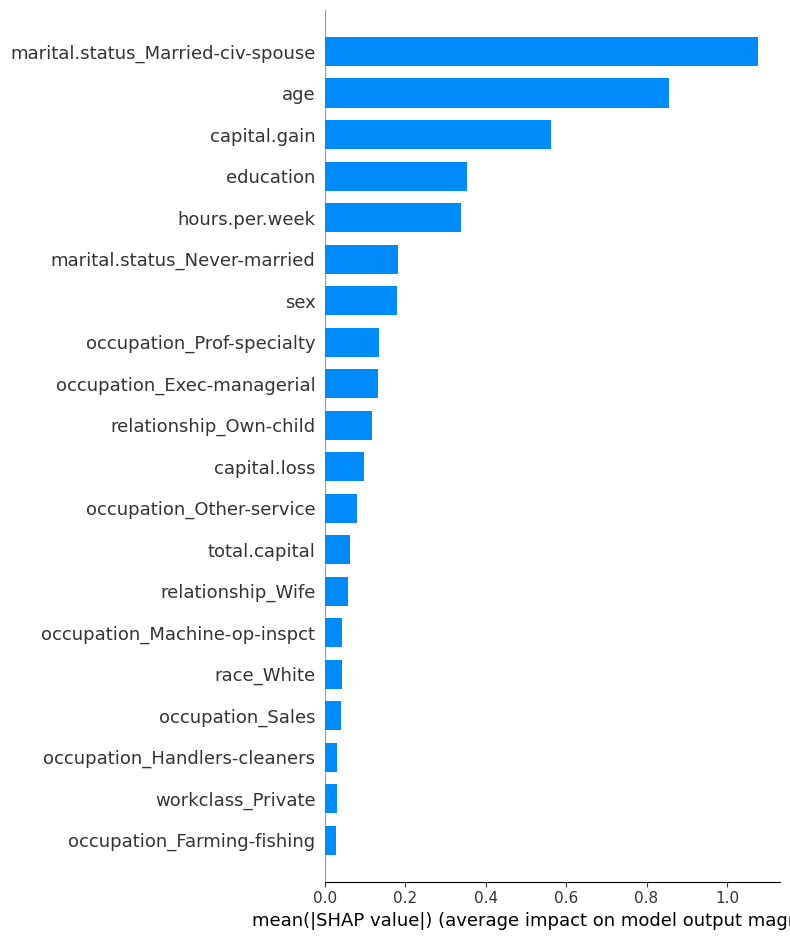

In [200]:
shap.summary_plot(shap_values,X_test,plot_type='bar')

# Save the Model

In [201]:
import joblib

joblib.dump(final_best_model,"employee_salary_model.joblib")
joblib.dump(scaler,"scaler_employee.joblib")

['scaler_employee.joblib']

# Predict the new data

In [202]:
X_train.columns.tolist()

['age',
 'education',
 'sex',
 'capital.gain',
 'capital.loss',
 'hours.per.week',
 'total.capital',
 'workclass_Federal-gov',
 'workclass_Local-gov',
 'workclass_Never-worked',
 'workclass_Private',
 'workclass_Self-emp-inc',
 'workclass_Self-emp-not-inc',
 'workclass_State-gov',
 'workclass_Without-pay',
 'marital.status_Married-AF-spouse',
 'marital.status_Married-civ-spouse',
 'marital.status_Married-spouse-absent',
 'marital.status_Never-married',
 'marital.status_Separated',
 'marital.status_Widowed',
 'occupation_Adm-clerical',
 'occupation_Armed-Forces',
 'occupation_Craft-repair',
 'occupation_Exec-managerial',
 'occupation_Farming-fishing',
 'occupation_Handlers-cleaners',
 'occupation_Machine-op-inspct',
 'occupation_Other-service',
 'occupation_Priv-house-serv',
 'occupation_Prof-specialty',
 'occupation_Protective-serv',
 'occupation_Sales',
 'occupation_Tech-support',
 'occupation_Transport-moving',
 'relationship_Not-in-family',
 'relationship_Other-relative',
 'relation

In [203]:
X_train.shape

(21799, 85)

In [204]:
input_data = pd.DataFrame({
    'age': [25],
    'workclass': ['Private'],
    'education': ['Bachelor'],
    'marital.status': ['Never-married'],
    'occupation': ['Tech-support'],
    'relationship': ['Not-in-family'],
    'race': ['White'],
    'sex': ['Male'],
    'capital.gain': [0],
    'capital.loss': [0],
    'hours.per.week': [40],
    'native.country': ['India'],
    'total.capital': [0]
})

In [205]:
load_model = joblib.load("employee_salary_model.joblib")

In [206]:
load_scaler = joblib.load("scaler_employee.joblib")

In [207]:
# onehot the new data 
input_encoded = pd.get_dummies(input_data)

In [208]:
# make the column same as X_train
input_encoded = input_encoded.reindex(
    columns = X_train.columns,
    fill_value=0
)

In [209]:
# check shape 
print(input_encoded.shape)

(1, 85)


In [210]:
prediction = lgbm.predict(input_encoded)

In [211]:
prediction
if prediction[0] == 1:
    print("Income: >50K")
else:
    print("Income: <=50K")

Income: <=50K


In [212]:
import os

print(os.getcwd())

C:\Users\Arjun Singh Tomar\anaconda_projects
